In [1]:
import numpy as np
import pandas as pd
from SWMM import SWMM_ENV as SWMM_ENV
from HC import HC as HC
import datetime
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import os
import yaml

import datetime

from MPC import pso
import pyswmm
from swmm_api.input_file import read_inp_file
from pyswmm import Simulation,Links,Nodes,RainGages,SystemStats
from swmm_api.input_file.sections.others import TimeseriesData
from swmm_api.input_file.sections import Control
from swmm_api.input_file.section_labels import TIMESERIES, CONTROLS
from swmm_api import read_rpt_file, SwmmReport

from scipy import stats
import math

from matplotlib.gridspec import GridSpec

E:\Anaconda\envs\drainage\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from matplotlib import rcParams

config = {
            "font.family": 'serif',
            "font.size": 22,                  
            "axes.titlesize": 25,            
            "axes.labelsize": 24,         
            "xtick.labelsize": 22,           
            "ytick.labelsize": 22,            
            "legend.fontsize": 22,            
            "pdf.fonttype": 42,             
            "ps.fonttype": 42,
            "mathtext.fontset": 'stix', # similar to Times New Roman
            "font.serif": ['Times New Roman'],
            'axes.unicode_minus': False 
         }
rcParams.update(config)

# Rainfall

In [3]:
# Load all training rainfall data
raindata = np.load('rainfall/training_raindata.npy').tolist()
num_rainfalls = 30  # total: 1000

In [4]:
rainreal = np.load('rainfall\\real_raindata.npy').tolist()

In [5]:
# Scale rainfall intensity（*5）
rainreal = [
    [
        [time, str(float(rain) * 5)]
        for time, rain in event
    ]
    for event in rainreal
]

# Load simulation results

In [6]:
r_base = np.load('./results_v7/HC.npy',allow_pickle=True).tolist()
r_GI = np.load('./results_v7/HC_GI.npy',allow_pickle=True).tolist()

r_HC = np.load('./results_v7/HC_GI_true.npy',allow_pickle=True).tolist()
r_MPC = np.load('./results_v7/MPC_GI.npy',allow_pickle=True).tolist()
r_DQN = np.load('./results_v7/DQN3_GI_new.npy',allow_pickle=True).tolist()
r_DQN_o = np.load('./results_v7/DQN3_GI.npy',allow_pickle=True).tolist()

In [8]:
r_base_real = np.load('./results_v7_m_real/HC.npy',allow_pickle=True).tolist()
r_GI_real = np.load('./results_v7_m_real/HC_GI.npy',allow_pickle=True).tolist()

r_HC_real = np.load('./results_v7_m_real/HC_GI_true.npy',allow_pickle=True).tolist()
r_MPC_real = np.load('./results_v7_m_real/MPC_GI.npy',allow_pickle=True).tolist()
r_DQN_real = np.load('./results_v7_m_real/DQN3_GI_new.npy',allow_pickle=True).tolist()
r_DQN_o_real = np.load('./results_v7_m_real/DQN3_GI.npy',allow_pickle=True).tolist()

In [9]:
start_idx = 50
one_step = 5 # 300s = 5min

# Bar Chart

In [10]:
color_GI = "slategrey" # no control + GI baseline
color_HC = "lightsteelblue" # BC/HC
color_DQN_o = "cornflowerblue" # DRL (old)
color_DQN_new = "mediumblue" # new DRL
color_MPC = "mediumslateblue" # MPC

normalize = False # Percentage：True
linewidth = 0.8
alpha = 0.9
figsize = (16, 6)

In [11]:
# Calculate cumulative flooding and CSO volume 
def last_flooding_cso(record, rainfall_key, flooding_path, cso_path):
    f = record[rainfall_key]
    for k in flooding_path:
        f = f[k] # Traverse nested dictionary structure（env, flooding)
    c = record[rainfall_key]
    for k in cso_path:
        c = c[k]
    f_arr = np.array(f)[2:] / 1000.0
    c_arr = np.array(c)[2:] / 1000.0
    # Retrieve value at the final timestep
    return float(f_arr[-1] + c_arr[-1])

In [12]:
# Performance improvement relative to the GI-only baseline
improve_GI = []
improve_HC = []
improve_MPC = []
improve_DQN_o = []
improve_DQN_new = []
denominators = [] # Baseline values used for normalization

for i in range(num_rainfalls):
    k = str(i + start_idx)
    rk = 'rainfall' + k

    # Baseline: No control
    base_last = last_flooding_cso(r_base, rk, ['env4', 'flooding'], ['env4', 'CSO'])

    # GI（env3）
    gi_last = last_flooding_cso(r_GI, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    
    # HC/BC（env5）
    hc_last = last_flooding_cso(r_HC, rk, ['env5', 'flooding'], ['env5', 'CSO'])

    # MPC
    mpc_last = last_flooding_cso(r_MPC, rk, ['flooding'], ['CSO'])

    # Original DRL
    dqn_o_last = last_flooding_cso(r_DQN_o, rk, ['env3', 'flooding'], ['env3', 'CSO'])

    # new DRL（env_new）
    dqn_new_last = last_flooding_cso(r_DQN, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])

    # Improvement (Baseline - Method)
    improve_GI.append(base_last - gi_last)
    improve_HC.append(base_last - hc_last)
    improve_MPC.append(base_last - mpc_last)
    improve_DQN_o.append(base_last - dqn_o_last)
    improve_DQN_new.append(base_last - dqn_new_last)

    denominators.append(base_last)

improve_GI = np.array(improve_GI)
improve_HC = np.array(improve_HC)
improve_MPC = np.array(improve_MPC)
improve_DQN_o = np.array(improve_DQN_o)
improve_DQN_new = np.array(improve_DQN_new)
denominators = np.array(denominators)

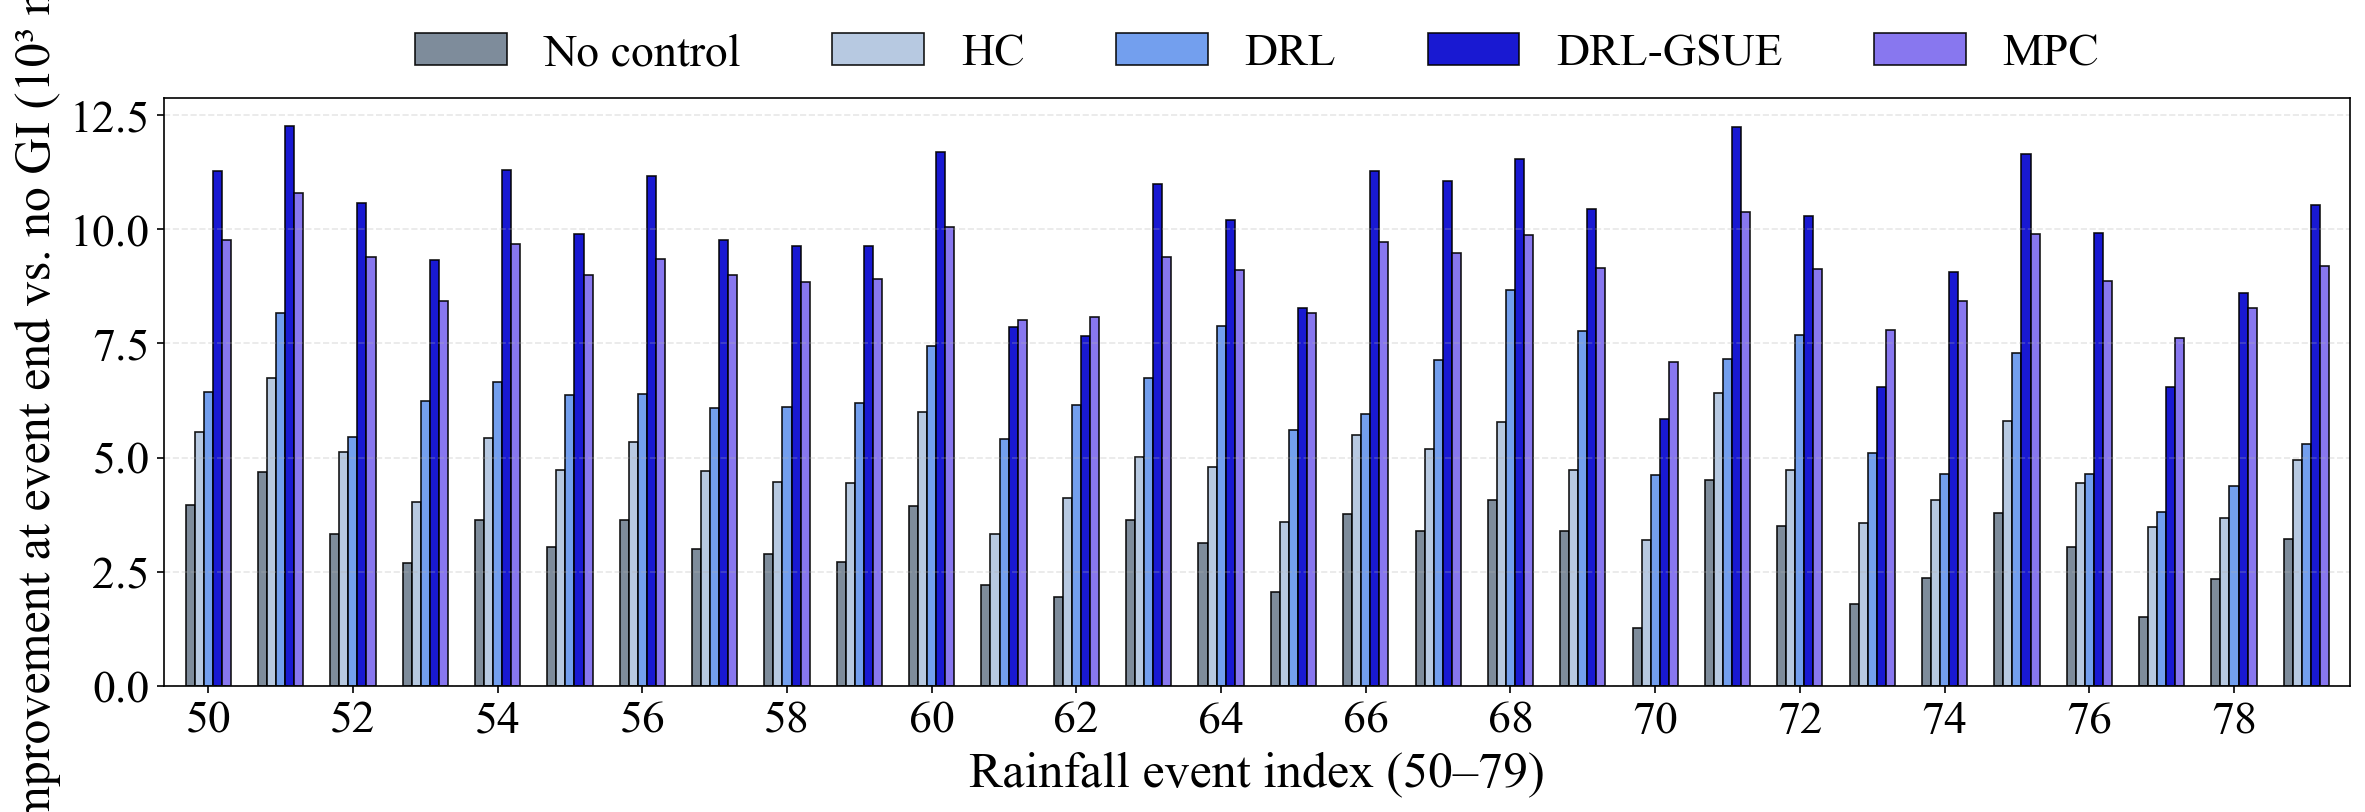

In [13]:
y_label = 'Improvement at event end vs. no GI (10³ m³)'
x = np.arange(num_rainfalls)
gap_factor = 1.6
x_base = np.arange(num_rainfalls) * gap_factor
bar_width = 0.2

plt.figure(figsize=figsize, dpi=150)

plt.bar(x_base - 2*bar_width, improve_GI, width=bar_width, color=color_GI, edgecolor='black', linewidth=linewidth, alpha=alpha, label='No control')
plt.bar(x_base - 1*bar_width, improve_HC, width=bar_width, color=color_HC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='HC')
plt.bar(x_base + 0*bar_width, improve_DQN_o, width=bar_width, color=color_DQN_o, edgecolor='black', linewidth=linewidth, alpha=alpha, label='DRL')
plt.bar(x_base + 1*bar_width, improve_DQN_new, width=bar_width, color=color_DQN_new, edgecolor='black', linewidth=linewidth, alpha=alpha, label='DRL-GSUE')
plt.bar(x_base + 2*bar_width, improve_MPC, width=bar_width, color=color_MPC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='MPC')

plt.xlabel('Rainfall event index ({}–{})'.format(start_idx, start_idx + num_rainfalls - 1))
plt.ylabel(y_label)
# plt.title('Improvement over no GI')

# Map x-axis ticks to the adjusted bar positions
tick_step = 2 if num_rainfalls <= 60 else 5
plt.xticks(x_base[::tick_step], [str(start_idx + i) for i in range(0, num_rainfalls, tick_step)], rotation=0)

ax = plt.gca()
ax.margins(x=0.01)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(ncol=5, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.18))
plt.tight_layout()

plt.savefig("results_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Select representative events based on peak intensity gradients, plus 4 real rainfalls

In [14]:
n_pick = 4     
n_pick_all = n_pick + 4
n_col = 2
n_row = math.ceil(n_pick_all / n_col)
figsize = (n_col * 8, n_row * 4)
dpi = 150

In [15]:
peak_values = []
for i in range(num_rainfalls):
    i += start_idx
    rain_event = raindata[i]
    event_rain_values = [float(v[1]) for v in rain_event] # intensity
    peak = max(event_rain_values) if len(event_rain_values) > 0 else 0.0
    peak_values.append(peak)

peak_values = np.array(peak_values)
sorted_indices = np.argsort(peak_values)  

# Uniform sampling across intensity gradients	
if n_pick == 1:
    chosen_local_idx = [len(sorted_indices)//2]
else:
    chosen_local_idx = np.linspace(0, len(sorted_indices)-1, n_pick).round().astype(int)

chosen_indices = sorted_indices[chosen_local_idx] # local index
chosen_events = [start_idx + int(i) for i in chosen_indices]

print("Selected events by peak gradient:", chosen_events)
print("Their peak intensities:", [float(peak_values[i]) for i in chosen_indices])

Selected events by peak gradient: [70, 64, 67, 51]
Their peak intensities: [81.38139521835302, 136.99042512240572, 161.3605100623962, 228.33281936149768]


In [16]:
# Real rainfalls
chosen_events.append(0)
chosen_events.append(1)
chosen_events.append(2)
chosen_events.append(3)

In [17]:
# Extract Flooding and CSO time series
def series_flooding_cso(record, rainfall_key, flooding_path, cso_path):
    f = record[rainfall_key]
    for k in flooding_path:
        f = f[k]
    c = record[rainfall_key]
    for k in cso_path:
        c = c[k]
    f_arr = np.array(f, dtype=float)[2:] / 1000.0
    c_arr = np.array(c, dtype=float)[2:] / 1000.0
    return f_arr + c_arr

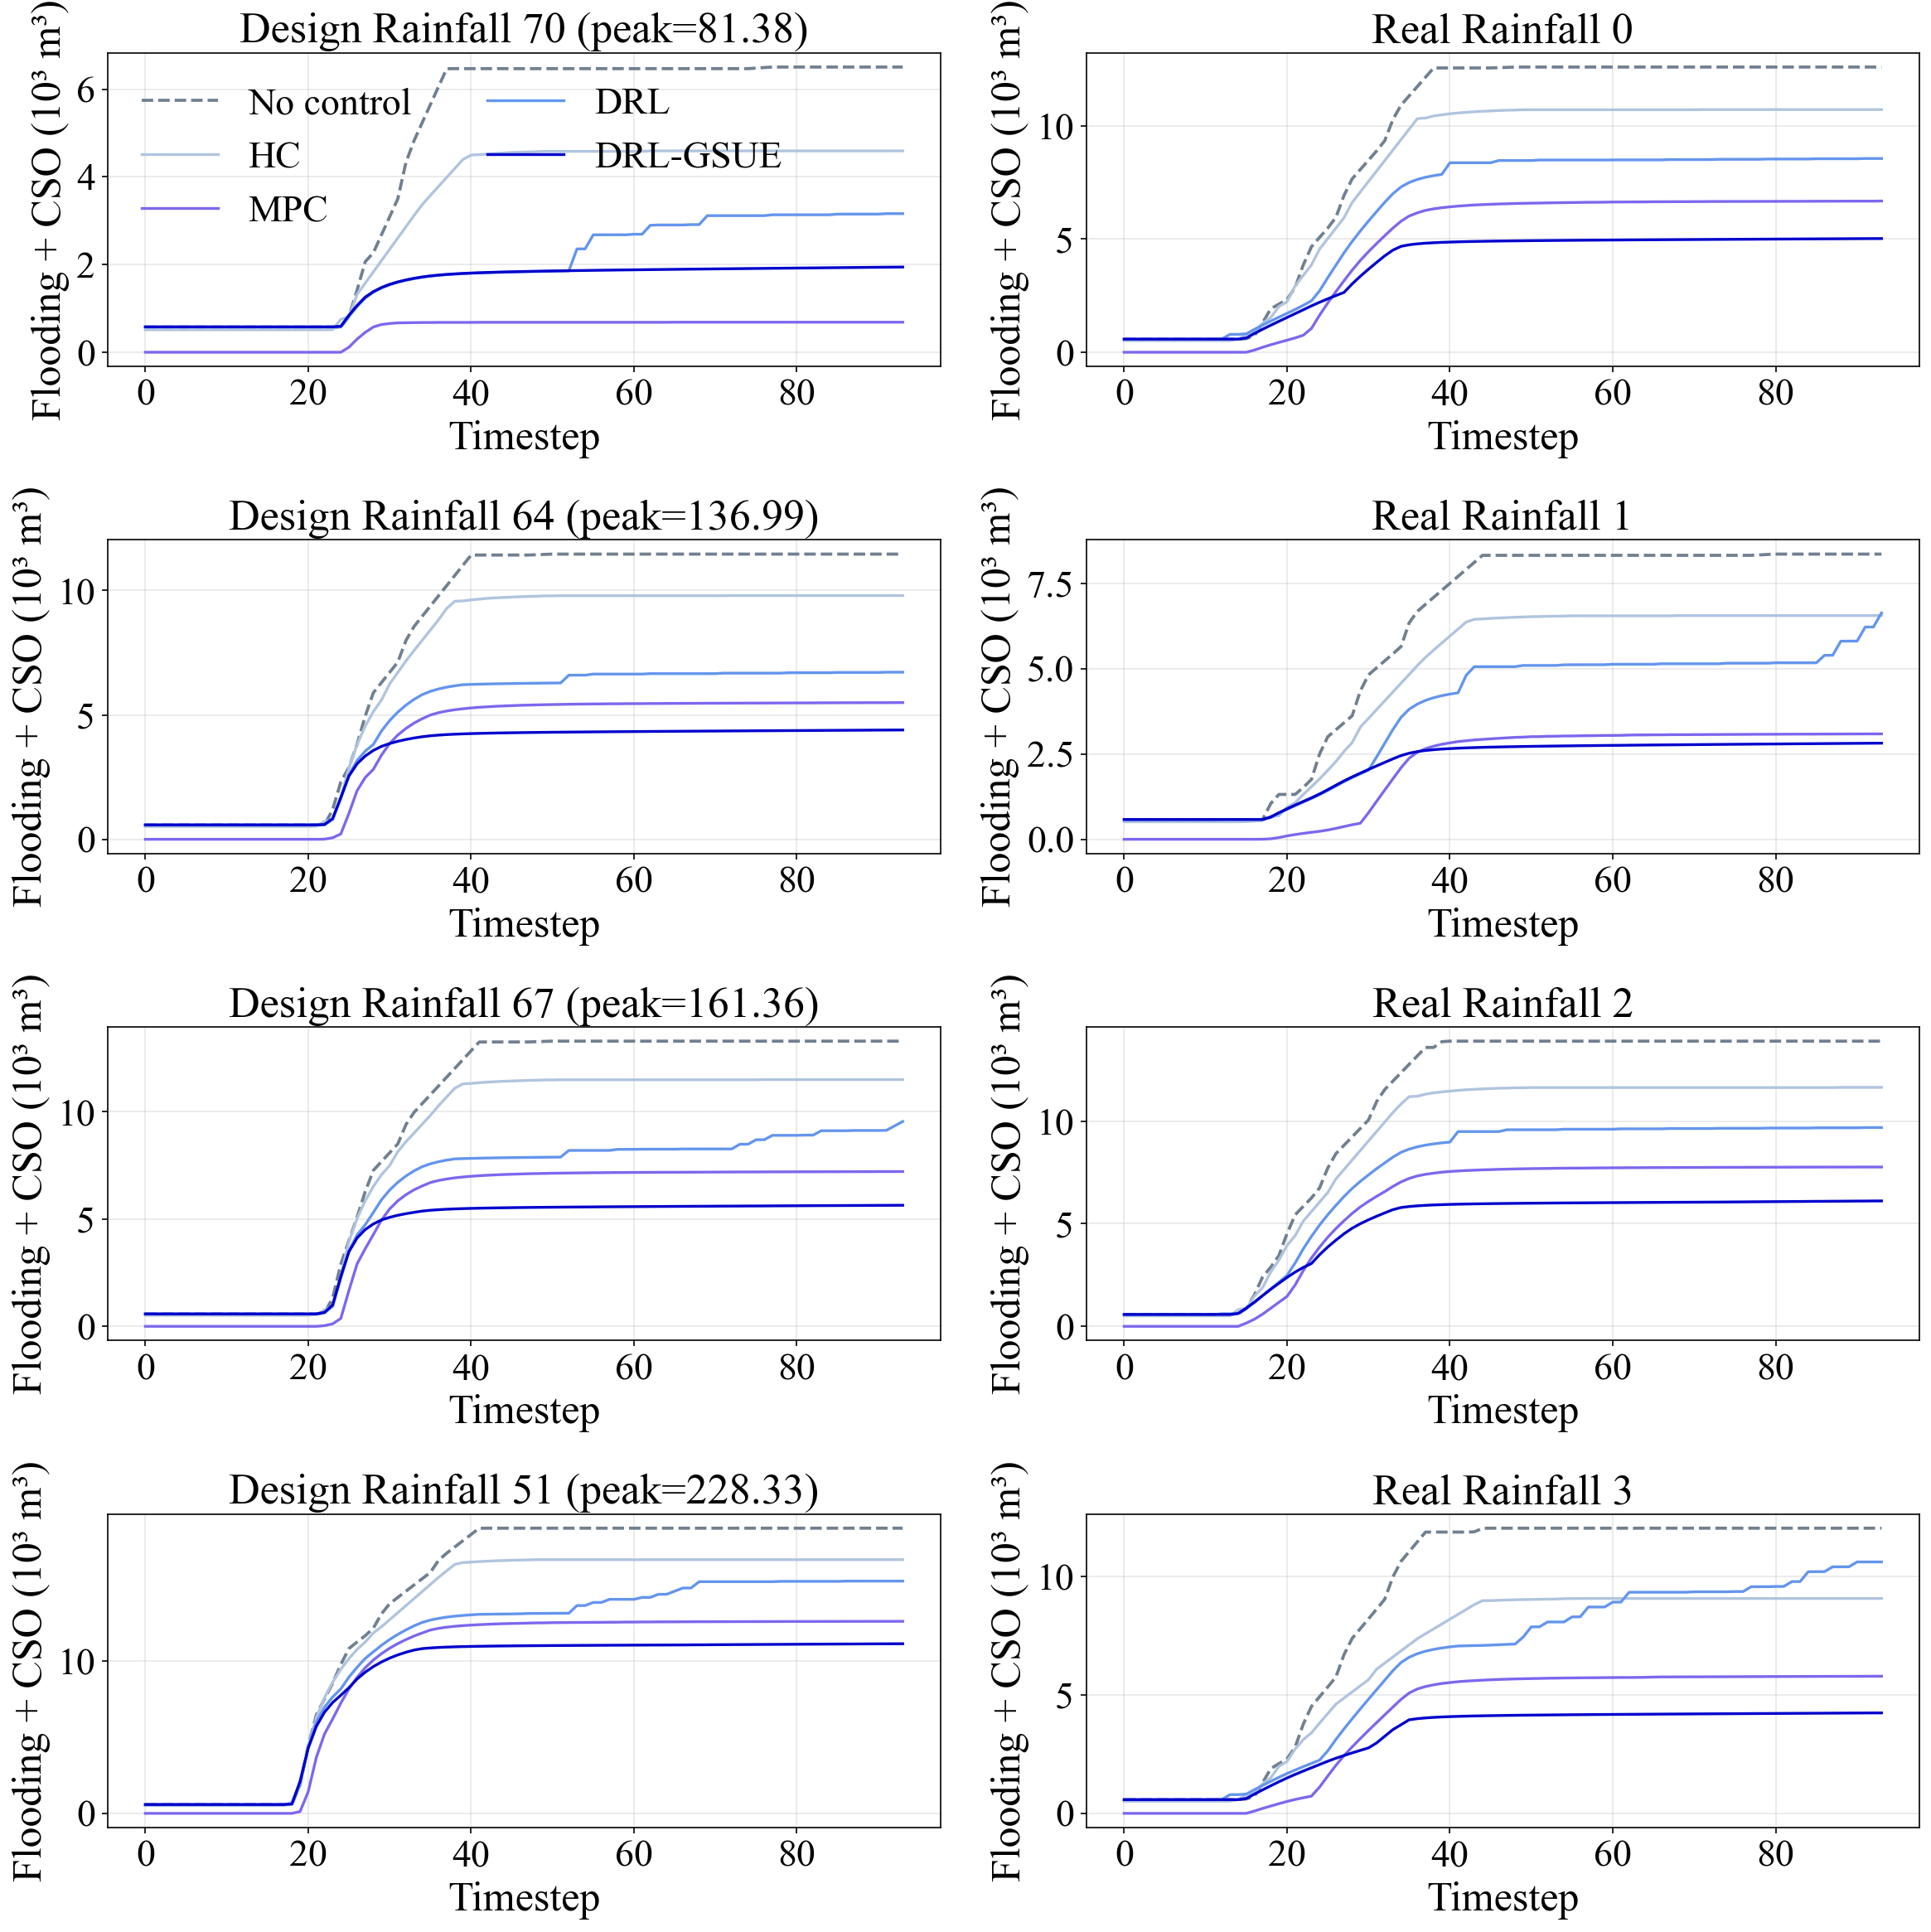

In [18]:
fig, ax = plt.subplots(n_row, n_col, figsize=figsize, dpi=dpi, squeeze=False)

for i, ev in enumerate(chosen_events):
    k = str(ev)
    rk = 'rainfall' + k
    col = i // n_row
    row = i % n_row

    # Baseline: no control + GI (HC_GI, env3)
    gi = series_flooding_cso(r_GI if i<4 else r_GI_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    # HC/BC
    hc = series_flooding_cso(r_HC if i<4 else r_HC_real, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    # Original DRL 
    dqn_o = series_flooding_cso(r_DQN_o if i<4 else r_DQN_o_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    # new DRL
    dqn_new = series_flooding_cso(r_DQN if i<4 else r_DQN_real, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    # MPC
    mpc = series_flooding_cso(r_MPC if i<4 else r_MPC_real, rk, ['flooding'], ['CSO'])

    ax[row, col].plot(gi, label='No control', color=color_GI, linewidth=1.8, linestyle='--')
    ax[row, col].plot(hc, label='HC', color=color_HC, linewidth=1.6)
    ax[row, col].plot(mpc, label='MPC', color=color_MPC, linewidth=1.6)
    ax[row, col].plot(dqn_o, label='DRL', color=color_DQN_o, linewidth=1.6)
    ax[row, col].plot(dqn_new, label='DRL-GSUE', color=color_DQN_new, linewidth=1.6)

    # Display peak intensity in the subplot title
    local_idx = ev - start_idx  # Obtain local index
    if i<4:
        ax[row, col].set_title(f'Design Rainfall {k} (peak={peak_values[local_idx]:.2f})')
    else:
        ax[row, col].set_title(f'Real Rainfall {k}')
    ax[row, col].set_ylabel('Flooding + CSO (10³ m³)')
    ax[row, col].set_xlabel('Timestep')
    ax[row, col].grid(True, alpha=0.3)

    if i == 0:
        ax[row, col].legend(ncol=2, frameon=False)

for i in range(n_pick_all, n_row * n_col):
    fig.delaxes(ax[i // n_col, i % n_col])

plt.tight_layout()
plt.show()

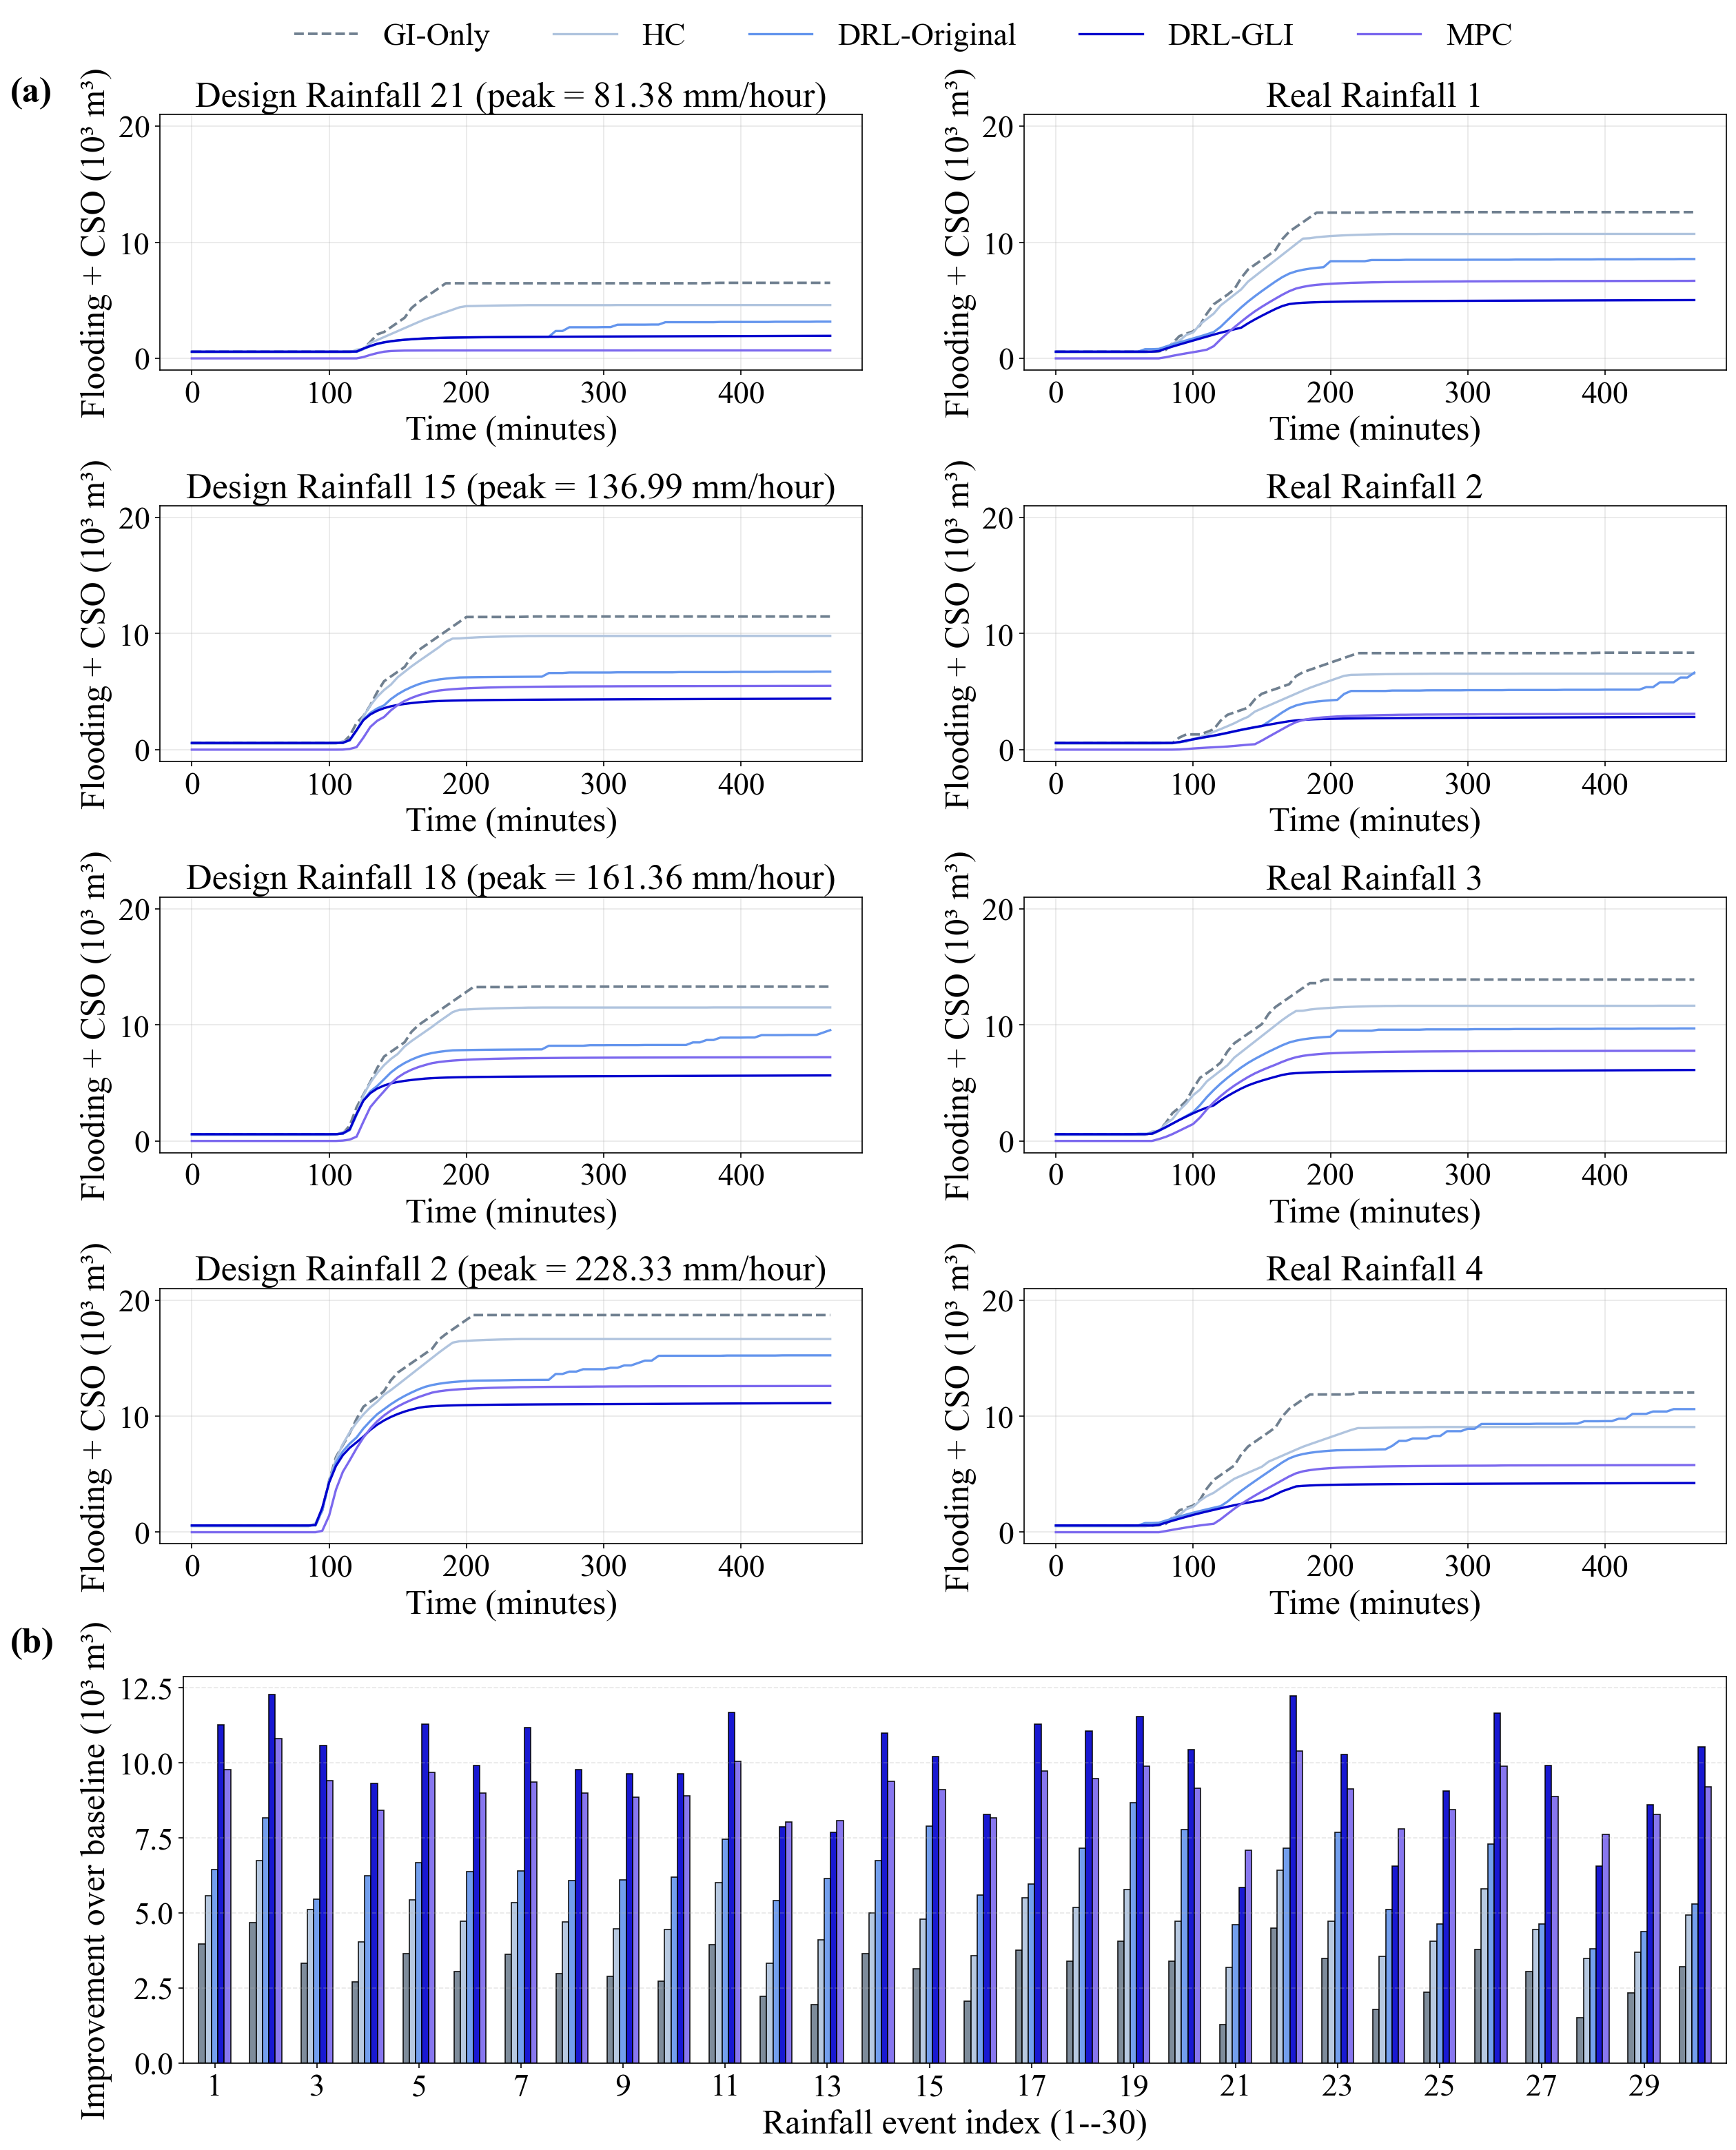

In [19]:
# Grid configuration for time series subplots
n_pick = 8
n_col = 2
n_row = math.ceil(n_pick / n_col)

figsize = (16, 20)
dpi = 150

color_GI = "slategrey" # no control + GI baseline
color_HC = "lightsteelblue" # BC/HC
color_DQN_o = "cornflowerblue" # Original DRL
color_DQN_new = "mediumblue" # new DRL
color_MPC = "mediumslateblue" # MPC

normalize = False
linewidth = 0.8
alpha = 0.9

# Initialize Figure and GridSpec layout
fig = plt.figure(figsize=figsize, dpi=dpi, constrained_layout=True)
# Outer layout: Split into upper and lower sections	
outer = GridSpec(
    nrows=2, ncols=1, figure=fig,
    height_ratios=[4, 1],  
    hspace=0.1          
)

# Upper section
gs_top = outer[0].subgridspec(
    nrows=n_row, ncols=n_col,
    wspace=0.1,  
    hspace=0.05   
)

axes_top = np.empty((n_row, n_col), dtype=object)
for r in range(n_row):
    for c in range(n_col):
        axes_top[r, c] = fig.add_subplot(gs_top[r, c])

# 3) Lower section
ax_bar = fig.add_subplot(outer[1, 0])

# Flooding and CSO time series
line_handles = []
line_labels = []

for i, ev in enumerate(chosen_events[:n_pick]):
    k = str(ev)
    rk = 'rainfall' + k
    col = i // n_row
    row = i % n_row
    ax = axes_top[row, col]

    # Baseline: no control + GI (HC_GI, env3)
    gi = series_flooding_cso(r_GI if i<4 else r_GI_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    # HC/BC
    hc = series_flooding_cso(r_HC if i<4 else r_HC_real, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    # Original DRL 
    dqn_o = series_flooding_cso(r_DQN_o if i<4 else r_DQN_o_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    # new DRL
    dqn_new = series_flooding_cso(r_DQN if i<4 else r_DQN_real, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    # MPC
    mpc = series_flooding_cso(r_MPC if i<4 else r_MPC_real, rk, ['flooding'], ['CSO'])

    N = len(gi) 
    minutes = np.arange(N) * one_step 
    
    h1, = ax.plot(minutes, gi, label='GI-Only', color=color_GI, linewidth=1.8, linestyle='--')
    h2, = ax.plot(minutes, hc, label='HC', color=color_HC, linewidth=1.6)
    h3, = ax.plot(minutes, dqn_o, label='DRL-Original', color=color_DQN_o, linewidth=1.6)
    h4, = ax.plot(minutes, dqn_new, label='DRL-GLI', color=color_DQN_new, linewidth=1.6)
    h5, = ax.plot(minutes, mpc, label='MPC', color=color_MPC, linewidth=1.6)

    line_handles.extend([h1, h2, h3, h4, h5])
    line_labels.extend([h.get_label() for h in [h1, h2, h3, h4, h5]])

    local_idx = ev - start_idx 
    if i<4:
        # ax.set_title(f'Design Rainfall {k} (peak={peak_values[local_idx]:.2f})')
        ax.set_title(f'Design Rainfall {str(int(k)-49)} (peak = {peak_values[local_idx]:.2f} mm/hour)') # -49: 50~79 to 1~30
    else:
        ax.set_title(f'Real Rainfall {str(int(k)+1)}')
    ax.set_ylim(-1, 21) 
    ax.set_ylabel('Flooding + CSO (10³ m³)')
    ax.set_xlabel('Time (minutes)')
    ax.grid(True, alpha=0.3)

for i in range(n_pick, n_row * n_col):
    fig.delaxes(axes_top[i // n_col, i % n_col])

unique = {}
for h, lab in zip(line_handles, line_labels):
    if lab not in unique:
        unique[lab] = h
handles_unique = list(unique.values())
labels_unique = list(unique.keys())

# Bar chart
gap_factor = 1.6
x_base = np.arange(num_rainfalls) * gap_factor
bar_width = 0.2

ax_bar.bar(x_base - 2*bar_width, improve_GI, width=bar_width, color=color_GI, edgecolor='black', linewidth=linewidth, alpha=alpha, label='GI only')
ax_bar.bar(x_base - 1*bar_width, improve_HC, width=bar_width, color=color_HC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='HC')
ax_bar.bar(x_base + 0*bar_width, improve_DQN_o, width=bar_width, color=color_DQN_o, edgecolor='black', linewidth=linewidth, alpha=alpha, label='DRL-Original')
ax_bar.bar(x_base + 1*bar_width, improve_DQN_new, width=bar_width, color=color_DQN_new, edgecolor='black', linewidth=linewidth, alpha=alpha, label='DRL-GSUE')
ax_bar.bar(x_base + 2*bar_width, improve_MPC, width=bar_width, color=color_MPC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='MPC')

# ax_bar.set_xlabel('Rainfall event index ({}--{})'.format(start_idx, start_idx + num_rainfalls - 1))
ax_bar.set_xlabel('Rainfall event index ({}--{})'.format(1, 30))
ax_bar.set_ylabel('Improvement over baseline (10³ m³)')
# ax_bar.set_title('Improvement over no GI')

tick_step = 2 if num_rainfalls <= 60 else 5
ax_bar.set_xticks(x_base[::tick_step])
# ax_bar.set_xticklabels([str(start_idx + i) for i in range(0, num_rainfalls, tick_step)], rotation=0)
ax_bar.set_xticklabels([str(i) for i in range(1, 31, tick_step)], rotation=0)

ax_bar.margins(x=0.01)
ax_bar.grid(axis='y', linestyle='--', alpha=0.3)

# Legend
fig.legend(
    handles_unique,
    labels_unique,
    loc='upper center',
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04), 
)

# (a) (b)
fig.text(-0.04, 1.00, "(a)", ha="left", va="top", fontsize=25, fontweight="bold")
fig.text(-0.04, 0.25, "(b)", ha="left", va="top", fontsize=25, fontweight="bold")

# plt.subplots_adjust(top=0.9)

plt.savefig("results_flooding_reward3_Train.png", dpi=300, bbox_inches="tight")
plt.show()

# Without MPC

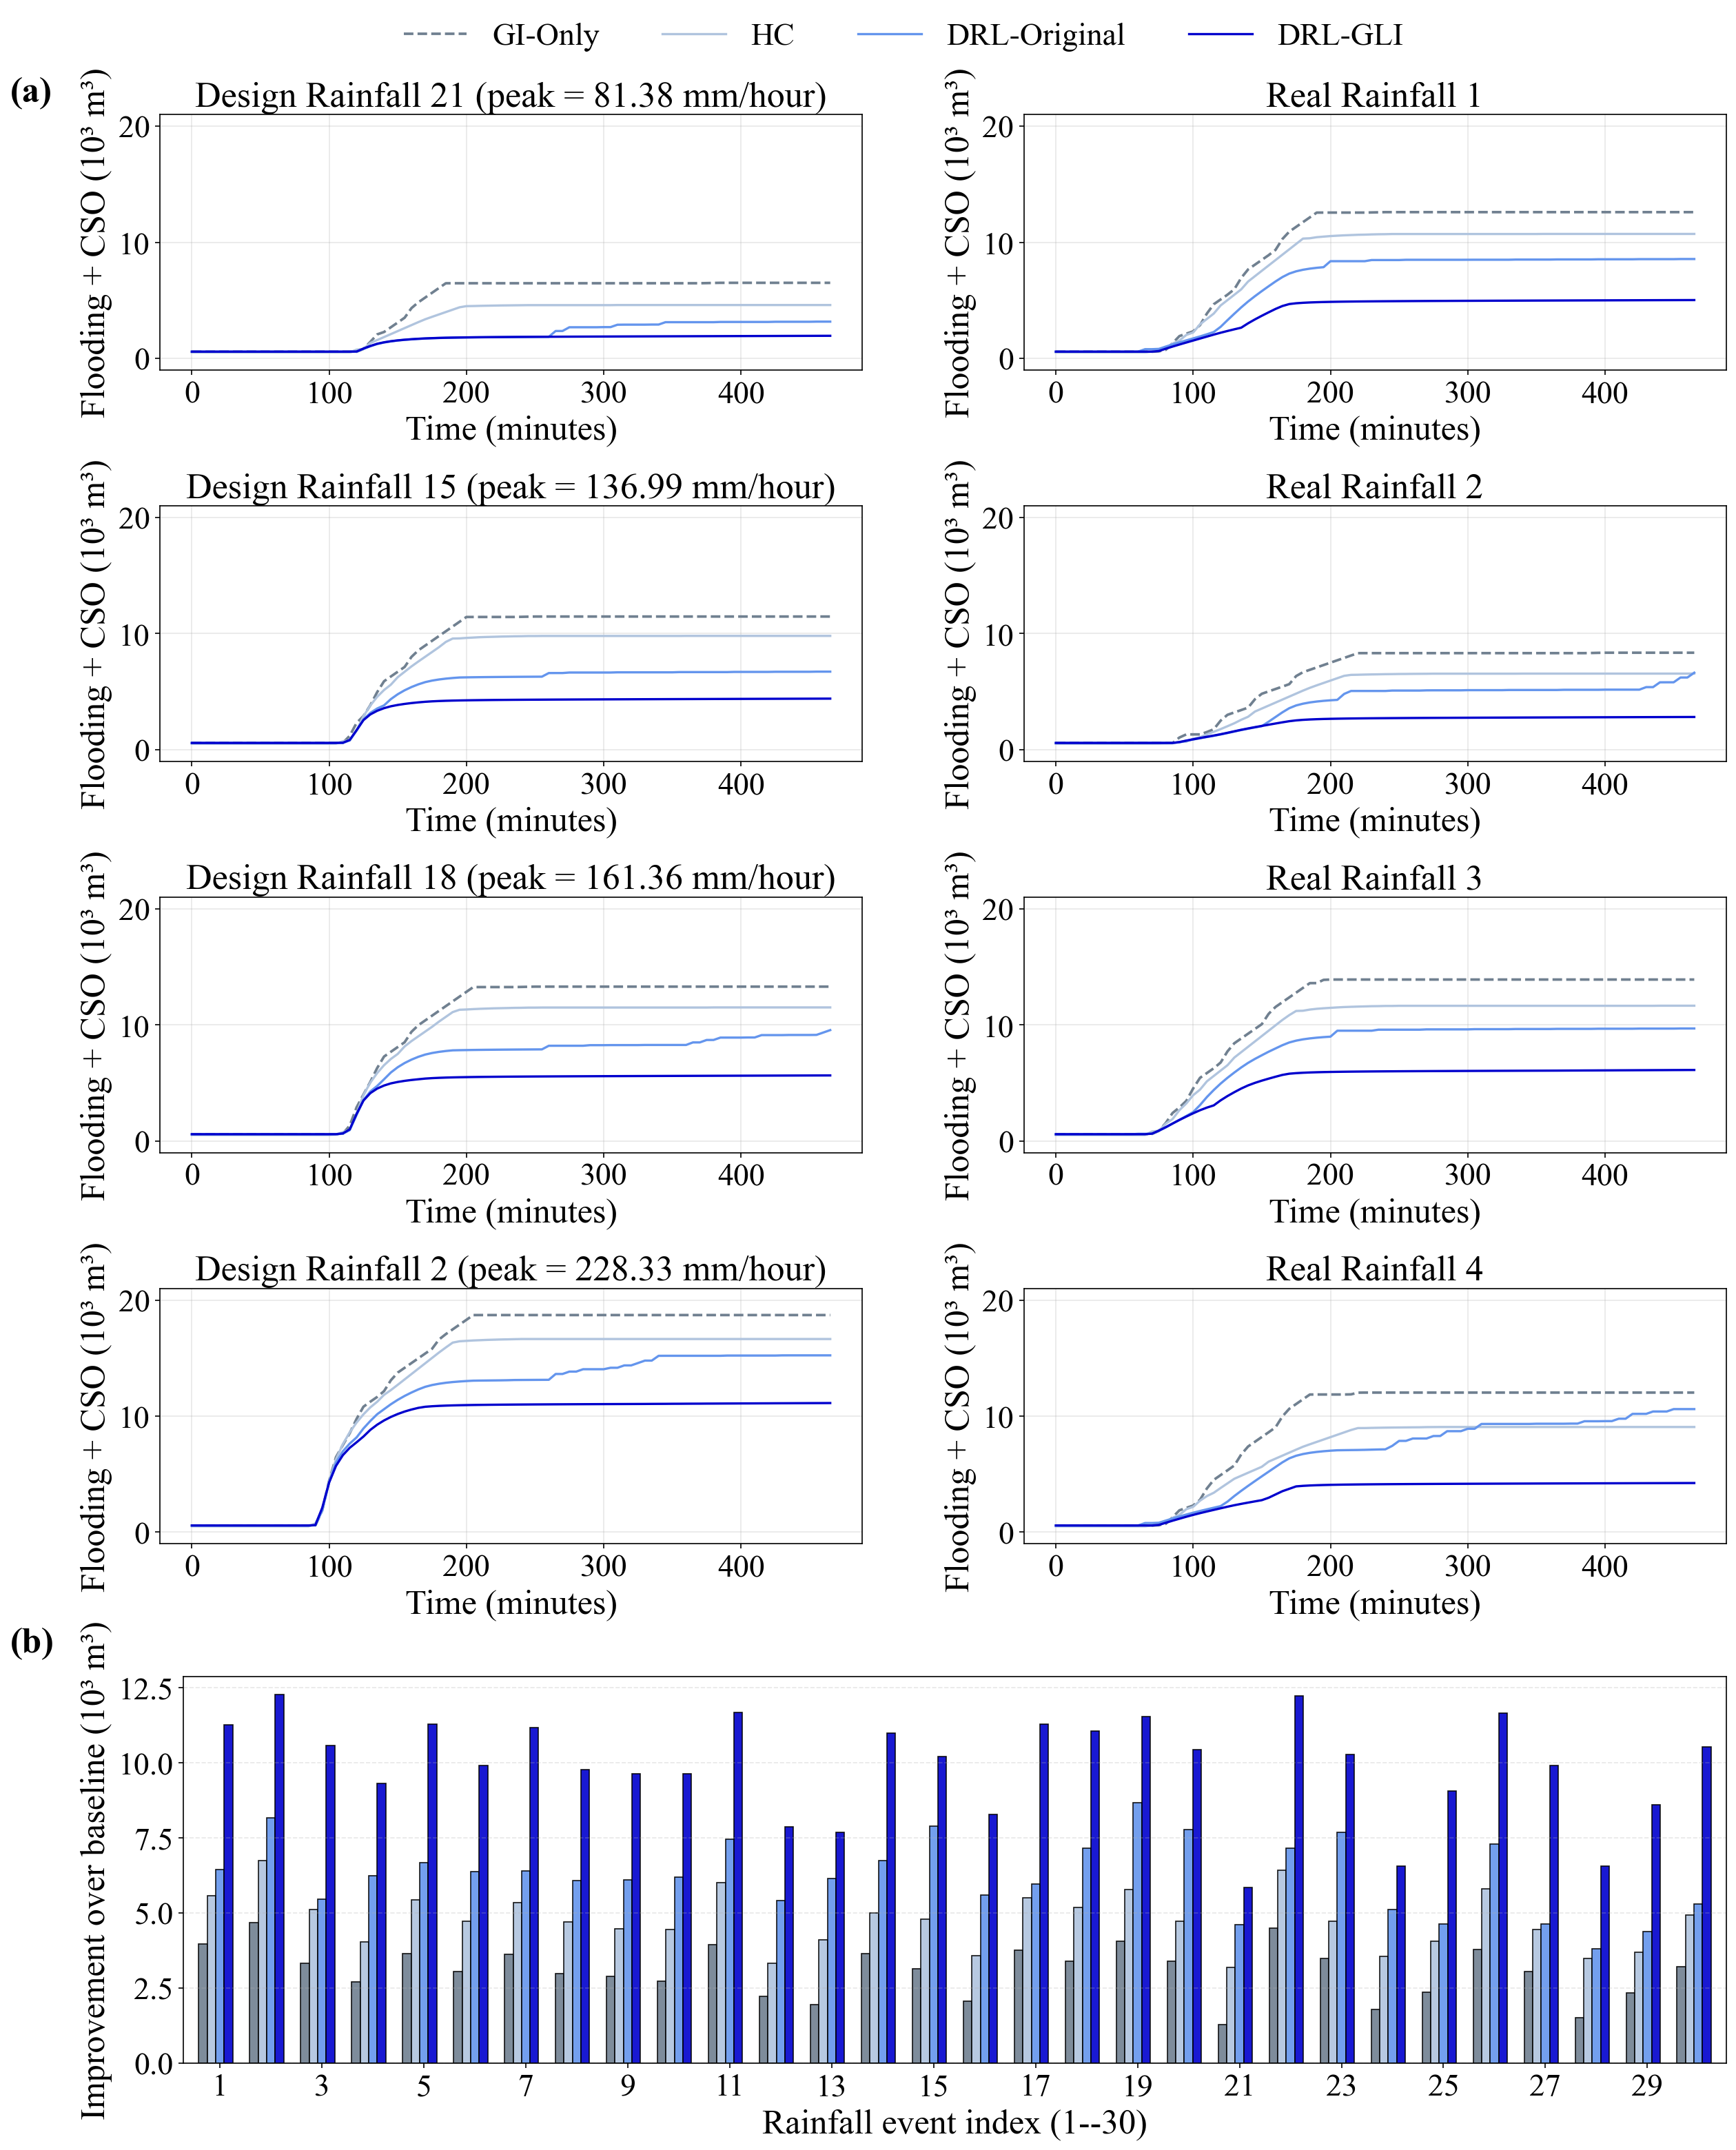

In [20]:
n_pick = 8
n_col = 2
n_row = math.ceil(n_pick / n_col)

figsize = (16, 20)
dpi = 150

color_GI = "slategrey" # no control + GI baseline
color_HC = "lightsteelblue" # BC/HC
color_DQN_o = "cornflowerblue" # Original DRL
color_DQN_new = "mediumblue" # new DRL
color_MPC = "mediumslateblue" # MPC

normalize = False  
linewidth = 0.8
alpha = 0.9

# Initialize Figure and GridSpec layout
fig = plt.figure(figsize=figsize, dpi=dpi, constrained_layout=True)
# Outer layout: Split into upper and lower sections
outer = GridSpec(
    nrows=2, ncols=1, figure=fig,
    height_ratios=[4, 1],  
    hspace=0.1             
)

# Upper section
gs_top = outer[0].subgridspec(
    nrows=n_row, ncols=n_col,
    wspace=0.1,  
    hspace=0.05   
)

axes_top = np.empty((n_row, n_col), dtype=object)
for r in range(n_row):
    for c in range(n_col):
        axes_top[r, c] = fig.add_subplot(gs_top[r, c])

# Lower section
ax_bar = fig.add_subplot(outer[1, 0])

# Flooding and CSO time series
line_handles = []
line_labels = []


for i, ev in enumerate(chosen_events[:n_pick]):
    k = str(ev)
    rk = 'rainfall' + k
    col = i // n_row
    row = i % n_row
    ax = axes_top[row, col]

    # Baseline: no control + GI (HC_GI, env3)
    gi = series_flooding_cso(r_GI if i<4 else r_GI_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    # HC/BC
    hc = series_flooding_cso(r_HC if i<4 else r_HC_real, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    # Original DRL 
    dqn_o = series_flooding_cso(r_DQN_o if i<4 else r_DQN_o_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    # new DRL
    dqn_new = series_flooding_cso(r_DQN if i<4 else r_DQN_real, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    # MPC
    # mpc = series_flooding_cso(r_MPC if i<4 else r_MPC_real, rk, ['flooding'], ['CSO'])

    N = len(gi) 
    minutes = np.arange(N) * one_step 
    
    h1, = ax.plot(minutes, gi, label='GI-Only', color=color_GI, linewidth=1.8, linestyle='--')
    h2, = ax.plot(minutes, hc, label='HC', color=color_HC, linewidth=1.6)
    h3, = ax.plot(minutes, dqn_o, label='DRL-Original', color=color_DQN_o, linewidth=1.6)
    h4, = ax.plot(minutes, dqn_new, label='DRL-GLI', color=color_DQN_new, linewidth=1.6)
    # h5, = ax.plot(minutes, mpc, label='MPC', color=color_MPC, linewidth=1.6)
   
    line_handles.extend([h1, h2, h3, h4]) 
    line_labels.extend([h.get_label() for h in [h1, h2, h3, h4]]) 

    local_idx = ev - start_idx  
    if i<4:
        # ax.set_title(f'Design Rainfall {k} (peak={peak_values[local_idx]:.2f})')
        ax.set_title(f'Design Rainfall {str(int(k)-49)} (peak = {peak_values[local_idx]:.2f} mm/hour)') # -49: 50~79 to 1~30
    else:
        ax.set_title(f'Real Rainfall {str(int(k)+1)}')
    ax.set_ylim(-1, 21) 
    ax.set_ylabel('Flooding + CSO (10³ m³)')
    ax.set_xlabel('Time (minutes)')
    ax.grid(True, alpha=0.3)

for i in range(n_pick, n_row * n_col):
    fig.delaxes(axes_top[i // n_col, i % n_col])

unique = {}
for h, lab in zip(line_handles, line_labels):
    if lab not in unique:
        unique[lab] = h
handles_unique = list(unique.values())
labels_unique = list(unique.keys())

# Bar chart
gap_factor = 1.2
x_base = np.arange(num_rainfalls) * gap_factor
bar_width = 0.2

ax_bar.bar(x_base - 2*bar_width, improve_GI, width=bar_width, color=color_GI, edgecolor='black', linewidth=linewidth, alpha=alpha, label='GI only')
ax_bar.bar(x_base - 1*bar_width, improve_HC, width=bar_width, color=color_HC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='HC')
ax_bar.bar(x_base + 0*bar_width, improve_DQN_o, width=bar_width, color=color_DQN_o, edgecolor='black', linewidth=linewidth, alpha=alpha, label='DRL-Original')
ax_bar.bar(x_base + 1*bar_width, improve_DQN_new, width=bar_width, color=color_DQN_new, edgecolor='black', linewidth=linewidth, alpha=alpha, label='DRL-GLI')
# ax_bar.bar(x_base + 2*bar_width, improve_MPC, width=bar_width, color=color_MPC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='MPC')

# ax_bar.set_xlabel('Rainfall event index ({}--{})'.format(start_idx, start_idx + num_rainfalls - 1))
ax_bar.set_xlabel('Rainfall event index ({}--{})'.format(1, 30))
ax_bar.set_ylabel('Improvement over baseline (10³ m³)')
# ax_bar.set_title('Improvement over no GI')

tick_step = 2 if num_rainfalls <= 60 else 5
ax_bar.set_xticks(x_base[::tick_step])
# ax_bar.set_xticklabels([str(start_idx + i) for i in range(0, num_rainfalls, tick_step)], rotation=0)
ax_bar.set_xticklabels([str(i) for i in range(1, 31, tick_step)], rotation=0)

ax_bar.margins(x=0.01)
ax_bar.grid(axis='y', linestyle='--', alpha=0.3)

# Legend
fig.legend(
    handles_unique,
    labels_unique,
    loc='upper center',
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04), 
)

# (a) (b)
fig.text(-0.04, 1.00, "(a)", ha="left", va="top", fontsize=25, fontweight="bold")
fig.text(-0.04, 0.25, "(b)", ha="left", va="top", fontsize=25, fontweight="bold")

# plt.subplots_adjust(top=0.9)

plt.savefig("results_flooding_reward3_Train_noMPC.png", dpi=300, bbox_inches="tight")
plt.show()